In [1]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib ;  import matplotlib.pyplot as plt
# 데이터 시각화:추세, 산점도 행렬 
import seaborn as sns
# Scale 변환:평균,표준편차 기준
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 맑은 고딕 적용
matplotlib.rc("font", family = "NanumGothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [2]:
data = pd.read_csv("/home/piai/반도체 데이터 분석/Final2_data.csv")
data.head()

,No_Die,Ox_Chamber,type,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,Target_error,Path
0,NOLSM32513132,2,0,1214.33,26.78,0.30,120,712.98,13,28,...,3.010000e+17,6.000000e+17,30795.856,103.513,854,154,141,none,0,21111
1,NOLSM32513133,2,0,977.98,30.90,0.14,137,714.41,13,29,...,3.030000e+17,6.000000e+17,32135.659,105.628,895,156,55,none,0,21122
2,NOLSM32513134,2,0,1175.95,31.11,0.25,116,710.27,13,30,...,2.980000e+17,6.000000e+17,31057.876,102.716,898,152,96,none,0,21133
3,NOLSM32513135,2,0,933.47,31.20,0.29,143,710.62,13,31,...,3.000000e+17,6.000000e+17,32140.435,102.902,879,155,105,none,0,21111
4,NOLSM32513136,2,0,1140.60,31.38,0.20,76,711.70,13,32,...,3.020000e+17,6.000000e+17,31985.989,101.465,882,155,79,none,0,21122


In [3]:
data.tail()

,No_Die,Ox_Chamber,type,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Lot_Num,Wafer_Num,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,Target_error,Path
14417,NOLSM32528517,3,0,1119.37,27.37,0.13,50,711.92,13,23,...,3.000000e+17,6.000000e+17,31877.793,101.566,914,155,134,none,0,32222
14418,NOLSM32528518,3,0,1263.81,31.62,0.18,112,696.98,13,24,...,3.000000e+17,6.000000e+17,30107.476,102.856,899,156,129,none,0,32311
14419,NOLSM32528519,3,0,964.04,38.56,0.08,78,706.11,13,25,...,2.990000e+17,6.000000e+17,32048.298,102.541,903,157,78,none,0,33111
14420,NOLSM32528520,3,0,1058.80,32.84,0.38,80,707.33,13,26,...,3.000000e+17,6.000000e+17,31221.150,104.359,879,155,60,none,0,33222
14421,NOLSM32528521,3,0,1046.03,44.90,0.31,89,715.99,13,27,...,3.000000e+17,6.000000e+17,31645.170,100.492,890,157,74,none,0,33333


In [4]:
data.columns

Index(['No_Die', 'Ox_Chamber', 'type', 'Temp_OXid', 'ppm', 'Pressure',
       'Oxid_time', 'thickness', 'Lot_Num', 'Wafer_Num', 'Datetime',
       'photo_soft_Chamber', 'resist_target', 'N2_HMDS', 'pressure_HMDS',
       'temp_HMDS', 'temp_HMDS_bake', 'time_HMDS_bake', 'spin1', 'spin2',
       'spin3', 'photoresist_bake', 'temp_softbake', 'time_softbake',
       'lithography_Chamber', 'Line_CD', 'Wavelength', 'Resolution',
       'Energy_Exposure', 'Etching_Chamber', 'Thin F4', 'Thin F3', 'Thin F2',
       'Thin F1', 'Temp_Etching', 'Source_Power', 'Selectivity', 'Chamber_Num',
       'Flux60s', 'Flux90s', 'Flux160s', 'Flux480s', 'Flux840s',
       'input_Energy', 'Temp_implantation', 'Furance_Temp', 'RTA_Temp',
       'Target', 'Error_message', 'Target_error', 'Path'],
      dtype='object')

## Oxidation 공정 (Temp_OXid, ppm, Pressure, Oxid_time)
### Temp_OXid 변수 운전 조건에 따른 그래프

## Photo_softbake 공정 ('N2_HMDS', 'pressure_HMDS', 'temp_HMDS', 'temp_HMDS_bake', 'time_HMDS_bake', 'spin1', 'spin2', 'spin3', 'photoresist_bake', 'temp_softbake', 'time_softbake')
### 운전 조건에 따른 그래프

## Photo_lithography 공정 ('Wavelength', 'Resolution', 'Energy_Exposure')
### 운전 조건에 따른 box plot

## Eching 공정 ('Temp_Etching','Source_Power','Selectivity')
### 운전 조건에 따른 box plot

## Ion Implantation 공정('Flux60s','Flux90s','Flux160s','Flux480s','Flux840s','input_Energy','Temp_implantation','Furance_Temp','RTA_Temp')
### 운전 조건에 따른 box plot

# 통계적 검정

### 다중 공선성 확인 (확인 결과 의미 없음)

P-value와 T-statistic 절대값을 동시에 고려:
P-value가 작고 T-statistic의 절대값이 큰 변수를 우선 선택하는 방법을 사용.

P-value가 0.001 이하이면서 T-statistic 절대값이 4 이상인 변수를 선택하는 기준으로 정함.

[Temp_implantation, Source_Power, Temp_OXid, Flux90s, Furance_Temp, ppm, spin1, Temp_softbake, spin2, Temp_Etching 를 고려 예정]

In [5]:
# 3개 변수 리스트
variables = ['Temp_OXid', 'Flux90s','ppm']

# 양품과 불량 데이터를 추출
df_양품 = data[data['Target_error'] == 0]
df_불량 = data[data['Target_error'] == 1]

# 결과를 저장할 딕셔너리
optimal_ranges_for_양품 = {}

for col in variables:
    # 양품 데이터의 IQR 계산
    Q1 = df_양품[col].quantile(0.25)
    Q3 = df_양품[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 기준 계산
    lower_bound_iqr = Q1 - 1.5 * IQR
    upper_bound_iqr = Q3 + 1.5 * IQR
    
    # IQR을 기준으로 양품 데이터에서 이상치 제외
    df_양품_정상 = df_양품[(df_양품[col] >= lower_bound_iqr) & (df_양품[col] <= upper_bound_iqr)]

    # 양품만 나오는 범위 (이상치 제외한 양품 범위)
    min_양품_정상 = df_양품_정상[col].min()
    max_양품_정상 = df_양품_정상[col].max()

    # 불량 데이터의 최소값과 최대값
    min_불량 = df_불량[col].min()
    max_불량 = df_불량[col].max()

    # 양품만 나오는 구간: 양품의 정상 범위에서 불량의 범위를 제외
    if max_양품_정상 > max_불량:
        # 양품의 최댓값이 불량의 최댓값보다 큰 경우: 0의 최댓값부터 1의 최댓값까지
        optimal_ranges_for_양품[col] = [(max_양품_정상, max_불량), (min_양품_정상, min_불량)]
    elif min_양품_정상 < min_불량:
        # 양품의 최소값이 불량의 최소값보다 작은 경우: 1의 최솟값 부터 0의 최솟값
        optimal_ranges_for_양품[col] = [(min_불량, min_양품_정상)]
    else:
        # 두 구간이 나올 수 있는 경우
        optimal_range_양품_lower = (min_양품_정상, min_불량)  # 양품의 끝점부터 불량의 시작점까지
        optimal_range_양품_upper = (max_불량, max_양품_정상)  # 불량의 끝점부터 양품의 시작점까지
        optimal_ranges_for_양품[col] = [optimal_range_양품_lower, optimal_range_양품_upper]

# 출력
for col, ranges in optimal_ranges_for_양품.items():
    if len(ranges) == 1:  # 구간이 하나만 나오는 경우
        print(f"{col}의 양품만 나오는 구간: ({ranges[0][1]:.2f}, {ranges[0][0]:.2f})")
    else:  # 두 구간이 나오는 경우
        print(f"{col}의 양품만 나오는 구간 (하위 구간): ({ranges[0][1]:.2f}, {ranges[0][0]:.2f})")
        print(f"{col}의 양품만 나오는 구간 (상위 구간): ({ranges[1][0]:.2f}, {ranges[1][1]:.2f})")


Temp_OXid의 양품만 나오는 구간 (하위 구간): (1294.70, 1311.32)
Temp_OXid의 양품만 나오는 구간 (상위 구간): (861.79, 871.00)
Flux90s의 양품만 나오는 구간 (하위 구간): (190000000000000000.00, 238000000000000000.00)
Flux90s의 양품만 나오는 구간 (상위 구간): (17434023167.00, 3846247470.00)
ppm의 양품만 나오는 구간 (하위 구간): (46.07, 50.05)
ppm의 양품만 나오는 구간 (상위 구간): (20.75, 21.80)


In [6]:
# 각 변수의 범위 조건을 설정
ranges = {
    'Temp_OXid': [(1294.70, 1311.32), (861.79, 871.00)],
    'Flux90s': [(190000000000000000.00, 238000000000000000.00), (17434023167.00, 3846247470.00)],
    'ppm': [(46.07, 50.05), (20.75, 21.80)],
}

In [7]:
import numpy as np
import random

# 변경된 값들을 저장할 리스트
changes_log = []

# 데이터에 대해 각 변수의 범위가 2개인 경우, 각 값마다 둘 중 하나의 범위를 랜덤으로 골라서 벗어나는 값을 범위 내 값으로 대체
for col, col_ranges in ranges.items():
    for i in range(len(data)):
        # 범위를 벗어나는 값인지 확인
        value = data.at[i, col]
        
        if len(col_ranges) == 2:
            # 범위가 2개인 경우, 두 범위 중 하나라도 충족하면 양품 범위 내에 있다고 판단
            in_range = (col_ranges[0][0] <= value <= col_ranges[0][1]) or (col_ranges[1][0] <= value <= col_ranges[1][1])
        else:
            # 범위가 1개인 경우, 해당 범위 내에 있는지 확인
            in_range = col_ranges[0][0] <= value <= col_ranges[0][1]
        
        # 벗어난 값인 경우
        if not in_range:
            # 각 값마다 범위를 임의로 선택
            lower, upper = random.choice(col_ranges)
            
            # 벗어난 값을 선택된 범위 내 임의의 값으로 대체
            new_value = np.random.uniform(lower, upper)
            data.at[i, col] = new_value
            
            # 변경 내역 기록
            changes_log.append({
                "변수": col,
                "변경 전 값": value,
                "변경 후 값": new_value,
                "대체 범위": (lower, upper)
            })

# 변경 내역 샘플 출력 (처음 10개만)
print("범위를 벗어난 값이 양품 범위 내 랜덤 값으로 대체되었습니다.\n")
for change in changes_log[:10]:  # 처음 10개만 출력
    print(f"변수: {change['변수']}, 변경 전 값: {change['변경 전 값']}, 변경 후 값: {change['변경 후 값']}, 대체 범위: {change['대체 범위']}")

범위를 벗어난 값이 양품 범위 내 랜덤 값으로 대체되었습니다.

변수: Temp_OXid, 변경 전 값: 1214.33, 변경 후 값: 1298.6566755447318, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 977.98, 변경 후 값: 1307.2316988457385, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 1175.95, 변경 후 값: 861.8840049676087, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 933.47, 변경 후 값: 1296.5230410478478, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 1140.6, 변경 후 값: 866.2994037153875, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 938.44, 변경 후 값: 863.8211624553624, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1033.84, 변경 후 값: 1309.0950306735754, 대체 범위: (1294.7, 1311.32)
변수: Temp_OXid, 변경 전 값: 1079.84, 변경 후 값: 870.4718332680227, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1032.7, 변경 후 값: 870.1620385297343, 대체 범위: (861.79, 871.0)
변수: Temp_OXid, 변경 전 값: 1132.11, 변경 후 값: 1300.441134600978, 대체 범위: (1294.7, 1311.32)


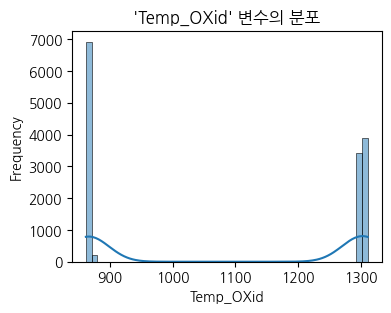

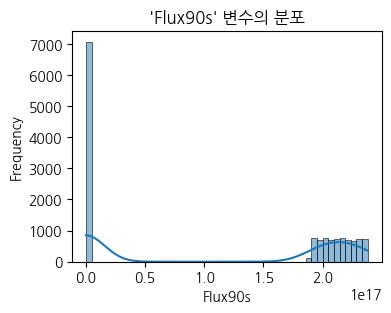

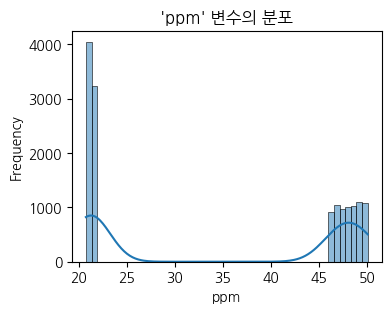

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 모든 변수에 대해 히스토그램과 KDE 시각화
for col in ranges.keys():
    plt.figure(figsize=(4, 3))
    sns.histplot(data[col], bins=50, kde=True)
    plt.title(f"'{col}' 변수의 분포")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [9]:
data.to_csv("최적운전조건3개만한거.csv", index=False)